In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/input.jpg')

resized = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)

h, w = img.shape[:2]
center = (w // 2, h // 2)
M_rotate = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated = cv2.warpAffine(img, M_rotate, (w, h))

shear_factor = 0.3
M_shear = np.float32([[1, shear_factor, 0],
                      [0, 1, 0]])
sheared = cv2.warpAffine(img, M_shear, (int(w + shear_factor * h), h))

negative = 255 - img

img_float = img.astype(np.float32)
c = 255 / np.log(1 + np.max(img_float))
log_transform = c * np.log(1 + img_float)
log_transform = np.clip(log_transform, 0, 255).astype(np.uint8)

gamma = 1.5
power_law = np.array(255 * (img_float / 255) ** gamma, dtype=np.uint8)


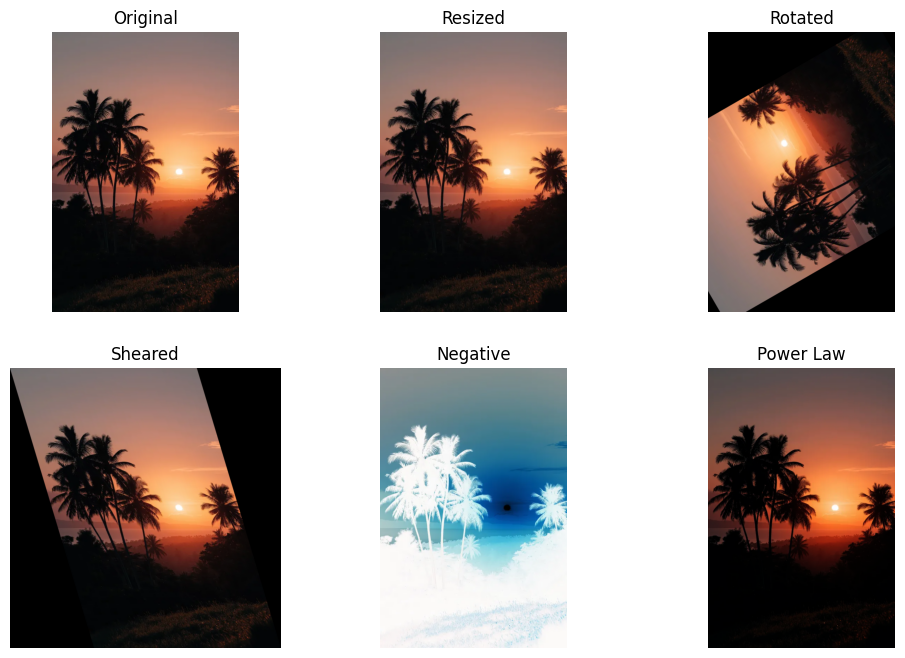

In [6]:
plt.figure(figsize=(12,8))

plt.subplot(231)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(232)
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Resized")
plt.axis('off')

plt.subplot(233)
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated")
plt.axis('off')

plt.subplot(234)
plt.imshow(cv2.cvtColor(sheared, cv2.COLOR_BGR2RGB))
plt.title("Sheared")
plt.axis('off')

plt.subplot(235)
plt.imshow(cv2.cvtColor(negative, cv2.COLOR_BGR2RGB))
plt.title("Negative")
plt.axis('off')

plt.subplot(236)
plt.imshow(cv2.cvtColor(power_law, cv2.COLOR_BGR2RGB))
plt.title("Power Law")
plt.axis('off')

plt.show()